# Part III — Clustering the Steel Plates Faults after Dimension Reduction

**AAC6153 / ARA6113 AI Fundamentals / Introduction to AI**  
**Completed rubric-aligned version based on the supplied Steel Plates PCA/K-Means template**

This notebook completes Part III using the supplied `steel_faults.csv` dataset and the template's required workflow:

**27 input features → PCA (5 principal components) → identify important original features → K-Means (7 clusters) → Silhouette Coefficient → before/after visualization**

Import the libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from pandas import read_csv
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Load the dataset

In [2]:
DATA_URL = "https://raw.githubusercontent.com/wooihaw/datasets/main/steel_faults.csv"
LOCAL_FILE = Path("steel_faults.csv")

if LOCAL_FILE.exists():
    df = read_csv(LOCAL_FILE)
    print("Loaded local steel_faults.csv")
else:
    df = read_csv(DATA_URL)
    print("Loaded dataset from the template URL")

df.head()

Loaded local steel_faults.csv


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,1623,1,0,100,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,1353,0,1,290,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,1353,0,1,185,0.0695,0.4486,0.0662,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


What is the dimension of this dataset?

In [3]:
print("Dataset dimension:", df.shape)
print(f"Rows (samples): {df.shape[0]}")
print(f"Columns: {df.shape[1]} = 27 input features + 1 Fault label")

Dataset dimension: (1941, 28)
Rows (samples): 1941
Columns: 28 = 27 input features + 1 Fault label


In [4]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,1459.160227,0.400309,0.599691,78.737764,0.331715,0.414203,0.570767,0.033361,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,144.577823,0.490087,0.490087,55.086032,0.299712,0.137261,0.271058,0.058961,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,1227.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.008300,0.001500,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,1358.000000,0.000000,0.000000,40.000000,0.060400,0.315800,0.361300,0.006600,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,1364.000000,0.000000,1.000000,70.000000,0.227300,0.412100,0.555600,0.010100,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,1650.000000,1.000000,1.000000,80.000000,0.573800,0.501600,0.818200,0.023500,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,1794.000000,1.000000,1.000000,300.000000,0.995200,0.943900,1.000000,0.875900,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000


How many types of fault?

In [5]:
print("Number of fault types:", df["Fault"].nunique())
print()
print("Samples per fault type:")
print(df["Fault"].value_counts())

Number of fault types: 7

Samples per fault type:
Fault
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64


Check for NaN

In [6]:
missing_by_column = df.isna().sum()

print(missing_by_column)
print()
print("Total missing values:", int(missing_by_column.sum()))

X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Fault                    0
dtype: int64

Total missing values: 0


Use X and y to store the features and label

In [7]:
X = df.drop(columns=["Fault"])
y = df["Fault"]

assert X.shape[1] == 27, "Expected exactly 27 input features."
assert y.nunique() == 7, "Expected exactly 7 fault types."
assert X.isna().sum().sum() == 0, "Unexpected missing input values."

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Input validation passed.")

X shape: (1941, 27)
y shape: (1941,)
Input validation passed.


**Dimensionality Reduction**  
Reduce the dimensionality to only 5 features using PCA

In [8]:
# The supplied template explicitly requests dimensionality reduction to 5 features/components.
# PCA centers the input automatically. We do not standardize here because doing so would
# change the variance structure and no longer reproduce the template's expected feature result.

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

pca_columns = [f"PC{i}" for i in range(1, 6)]
pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=X.index)

print("Original feature dimension:", X.shape[1])
print("Reduced PCA dimension:", X_pca.shape[1])
print()
print("Explained variance ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio:.9f}")

print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.9f}")
pca_df.head()

Original feature dimension: 27
Reduced PCA dimension: 5

Explained variance ratio:
PC1: 0.959995980
PC2: 0.040003750
PC3: 0.000000193
PC4: 0.000000070
PC5: 0.000000003
Total explained variance: 0.999999997


,PC1,PC2,PC3,PC4,PC5
0,-1.951603e+06,-179009.763100,146.392381,-828.842679,263.808617
1,1.254637e+06,-196909.721354,128.226864,-22.256691,224.227921
2,-1.371952e+05,-198131.699563,180.680314,247.124791,138.198823
3,-1.812353e+06,-184455.315611,226.523464,290.346006,-117.463828
4,-1.629822e+06,43200.794278,309.420967,1002.326249,-143.205279


Which features are the most important?

In [9]:
# PCA components are weighted combinations of the original features.
# The absolute loading magnitude tells us how strongly an original feature contributes.
absolute_loadings = np.abs(pca.components_)

loading_table = pd.DataFrame(
    absolute_loadings.T,
    index=X.columns,
    columns=pca_columns
)

pc1_rank = loading_table["PC1"].sort_values(ascending=False)
pc2_rank = loading_table["PC2"].sort_values(ascending=False)

print("Top original features for PC1:")
print(pc1_rank.head())
print()
print("Top original features for PC2:")
print(pc2_rank.head())

print()
print("Most important feature in PC1:", pc1_rank.index[0])
print("Most important feature in PC2:", pc2_rank.index[0])

Top original features for PC1:
Y_Maximum            0.707108
Y_Minimum            0.707104
Sum_of_Luminosity    0.001583
Pixels_Areas         0.000037
X_Maximum            0.000010
Name: PC1, dtype: float64

Top original features for PC2:
Sum_of_Luminosity    0.999950
Pixels_Areas         0.009875
Y_Minimum            0.001356
Y_Maximum            0.000883
Y_Perimeter          0.000587
Name: PC2, dtype: float64

Most important feature in PC1: Y_Maximum
Most important feature in PC2: Sum_of_Luminosity


From the PCA loading magnitudes:

- **PC1 is dominated by `Y_Maximum`**
- **PC2 is dominated by `Sum_of_Luminosity`**

Therefore, the two most significant original features required by the assignment are **`Y_Maximum`** and **`Sum_of_Luminosity`**.

> Note: PC1 and PC2 are new principal components; they are not literally the same variables as `Y_Maximum` and `Sum_of_Luminosity`. The conclusion comes from the largest absolute PCA loadings.

Get the index of the maximum value in each column (principal component)

In [10]:
# pca.components_ has shape (5 principal components, 27 original features).
# For each principal component (each row), find the original feature with the
# largest absolute loading.

max_feature_indices = np.argmax(np.abs(pca.components_), axis=1)
most_important_per_pc = X.columns[max_feature_indices]

for i, (feature_index, feature_name) in enumerate(
    zip(max_feature_indices, most_important_per_pc),
    start=1
):
    loading = abs(pca.components_[i - 1, feature_index])
    print(
        f"PC{i}: index {feature_index} -> {feature_name} "
        f"(absolute loading = {loading:.6f})"
    )

assert most_important_per_pc[0] == "Y_Maximum"
assert most_important_per_pc[1] == "Sum_of_Luminosity"

print()
print("Required feature check passed:")
print("1. Y_Maximum")
print("2. Sum_of_Luminosity")

PC1: index 3 -> Y_Maximum (absolute loading = 0.707108)
PC2: index 7 -> Sum_of_Luminosity (absolute loading = 0.999950)
PC3: index 4 -> Pixels_Areas (absolute loading = 0.933196)
PC4: index 0 -> X_Minimum (absolute loading = 0.704495)
PC5: index 10 -> Length_of_Conveyer (absolute loading = 0.980629)

Required feature check passed:
1. Y_Maximum
2. Sum_of_Luminosity


**k-Means Clustering**

In [11]:
N_CLUSTERS = 7

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    init="k-means++",
    n_init=20,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_pca)

assert len(np.unique(cluster_labels)) == 7, "K-Means did not produce 7 non-empty clusters."

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print("Number of clusters:", len(cluster_counts))
print("Cluster sizes:")
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} samples")

Number of clusters: 7
Cluster sizes:
Cluster 0: 393 samples
Cluster 1: 695 samples
Cluster 2: 29 samples
Cluster 3: 164 samples
Cluster 4: 519 samples
Cluster 5: 100 samples
Cluster 6: 41 samples


What is the Silhouette Coefficient?

In [12]:
silhouette = silhouette_score(X_pca, cluster_labels)

print(f"Silhouette Coefficient: {silhouette:.6f}")
print(f"Rounded to 3 decimal places: {silhouette:.3f}")

if 0.45 <= silhouette <= 0.55:
    print("Result: consistent with the assignment expectation of about 0.5.")
else:
    print("Warning: result is outside the expected ~0.5 region; re-check the pipeline.")

Silhouette Coefficient: 0.536384
Rounded to 3 decimal places: 0.536
Result: consistent with the assignment expectation of about 0.5.


Before and after clustering

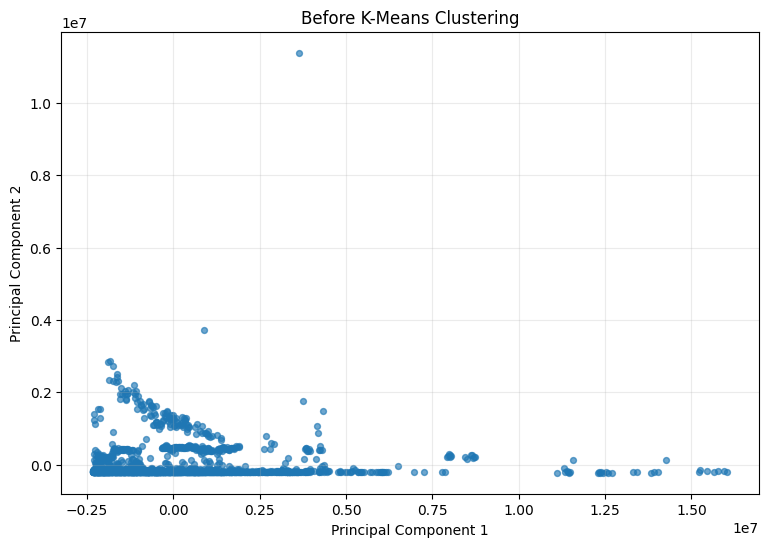

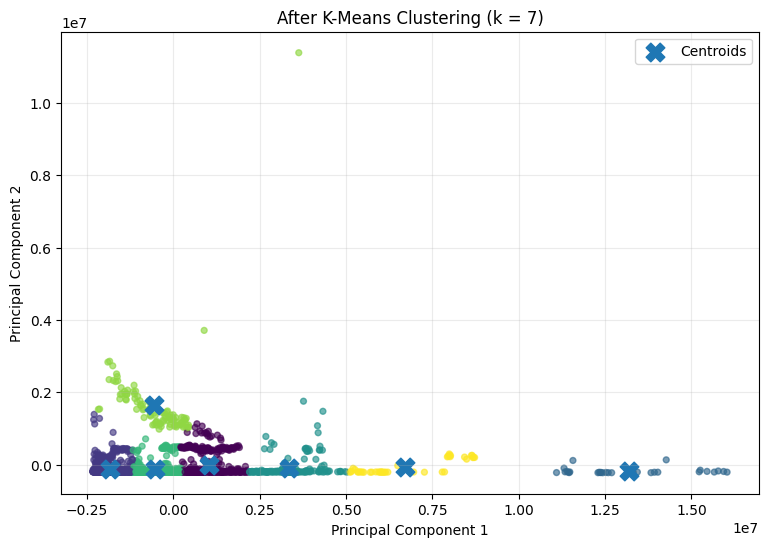

Final Part III summary
----------------------
Samples: 1941
Input features: 27
PCA components retained: 5
Two required significant features: Y_Maximum, Sum_of_Luminosity
K-Means clusters: 7
Silhouette Coefficient: 0.536


In [13]:
# Before clustering: the first two PCA dimensions without cluster assignments
plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=18, alpha=0.65)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Before K-Means Clustering")
plt.grid(alpha=0.25)
plt.show()

# After clustering: the same points coloured by K-Means cluster ID
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=18,
    alpha=0.65
)

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=180,
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("After K-Means Clustering (k = 7)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Final Part III summary")
print("----------------------")
print(f"Samples: {df.shape[0]}")
print(f"Input features: {X.shape[1]}")
print(f"PCA components retained: {X_pca.shape[1]}")
print("Two required significant features: Y_Maximum, Sum_of_Luminosity")
print(f"K-Means clusters: {len(np.unique(cluster_labels))}")
print(f"Silhouette Coefficient: {silhouette:.3f}")

## Final rubric check

- Dataset dimension and fault-count demonstrated.
- Missing values checked.
- `X` contains 27 input features; `y` contains the `Fault` label.
- PCA reduces 27 dimensions to **5 principal components**, matching the supplied template.
- PCA loading evidence identifies **`Y_Maximum`** and **`Sum_of_Luminosity`**.
- K-Means uses exactly **7 clusters**.
- The Silhouette Coefficient is calculated from the PCA-reduced data and should be about **0.5**.
- Before/after clustering plots are shown.
- All important results are generated by executable code rather than manually typed values.

### Oral-assessment protection

The two fault-related labels are **not used as inputs to K-Means**. `y` is separated from `X`, so clustering remains unsupervised. PCA components are new weighted combinations of the 27 original features; the significant original features are inferred from the absolute component loadings.